In [31]:
# @title Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set paths
DRIVE_DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/anomaly-data'
DRIVE_OUT_DIR = '/content/drive/MyDrive/Colab Notebooks/anomaly-models'
import os
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import json
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [45]:
# Load from Google Drive
X_train = np.load(f'{DRIVE_DATA_DIR}/X_train_scale.npy')
X_val = np.load(f'{DRIVE_DATA_DIR}/X_val_scale.npy')
X_test = np.load(f'{DRIVE_DATA_DIR}/X_test_scale.npy')
y_train = np.load(f'{DRIVE_DATA_DIR}/y_train.npy').flatten()
y_val = np.load(f'{DRIVE_DATA_DIR}/y_val.npy').flatten()
y_test = np.load(f'{DRIVE_DATA_DIR}/y_test.npy').flatten()

n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')
print(f'n_features: {n_features}, n_classes: {n_classes}')

X_train: (313539, 76)
X_val:   (67188, 76)
X_test:  (67188, 76)
n_features: 76, n_classes: 10


In [46]:
n_features   = X_train.shape[1]   # 76
n_classes    = len(np.unique(y_train))  # 10
SEQ_LENGTH   = n_features         # 76 tokens (one per feature)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Features: {n_features}, Classes: {n_classes}")

# ── SMOTE ──
class_counts = np.bincount(y_train.astype(int))
target_per_class = int(class_counts.max() * 0.1)

sampling_strategy = {}
for i, count in enumerate(class_counts):
    if count < target_per_class:
        sampling_strategy[i] = target_per_class

print(f"\nSMOTE target: {target_per_class:,}/class")
print(f"Classes to oversample: {list(sampling_strategy.keys())}")

smote = SMOTE(sampling_strategy=sampling_strategy, k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: {X_train_smote.shape}")

Train: (313539, 76), Val: (67188, 76), Test: (67188, 76)
Features: 76, Classes: 10

SMOTE target: 25,083/class
Classes to oversample: [1, 2, 3, 4, 5, 6, 7, 8, 9]
After SMOTE: (476579, 76)


In [47]:
# ── Class weights ──
n_smote = len(y_train_smote)
smote_counts = np.bincount(y_train_smote.astype(int))
class_weights = n_smote / (n_classes * smote_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("\nClass weights:")
for i, w in enumerate(class_weights):
    print(f"  {CLASS_NAMES[i]:<15} {w:.4f}")



Class weights:
  Benign          0.1900
  Analysis        1.9000
  Backdoor        1.9000
  DoS             1.9000
  Exploits        1.9000
  Fuzzers         1.9000
  Generic         1.9000
  Reconnaissance  1.9000
  Shellcode       1.9000
  Worms           1.9000


In [48]:
# ── Model ──
class TabTransformer(nn.Module):
    def __init__(self, n_features, n_classes, d_model=32, nhead=4, n_layers=4, d_ff=128, dropout=0.2):
        super().__init__()
        self.n_features = n_features

        # Step 1: embed each of the 76 features into a d_model-dim vector
        self.feature_embedding = nn.Linear(1, d_model)

        # Step 2: learnable positional encoding (feature index 0..75)
        self.pos_encoding = nn.Parameter(torch.randn(1, n_features, d_model) * 0.02)

        # Step 3: Transformer Encoder layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="relu",
            batch_first=True,
            norm_first=True,  # Pre-norm: more stable training
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Step 4: MLP head (pooled vector → 10 classes)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d_model // 2, n_classes),
        )

    def forward(self, x):
        # x: (batch, n_features) = (B, 76)
        # Reshape to (B, 76, 1) — each feature as its own "token"
        x = x.unsqueeze(-1)

        # Embed each feature: (B, 76, 1) → (B, 76, d_model)
        x = self.feature_embedding(x)

        # Add positional encoding
        x = x + self.pos_encoding

        # Transformer Encoder: (B, 76, d_model) → (B, 76, d_model)
        x = self.transformer(x)

        # Mean pool over all features: (B, 76, d_model) → (B, d_model)
        x = x.mean(dim=1)

        # Head: (B, d_model) → (B, n_classes)
        x = self.head(x)
        return x


D_MODEL  = 32   # embedding dimension
NHEAD    = 4    # attention heads
N_LAYERS = 4    # transformer layers
D_FF     = 128  # feed-forward hidden dim

In [49]:
model = TabTransformer(
    n_features=n_features,
    n_classes=n_classes,
    d_model=D_MODEL,
    nhead=NHEAD,
    n_layers=N_LAYERS,
    d_ff=D_FF,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: {total_params:,} parameters")
print(model)


Model: 54,074 parameters
TabTransformer(
  (feature_embedding): Linear(in_features=1, out_features=32, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=32, out_features=16, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1

/tmp/ipykernel_2922/903800874.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [54]:
X_train_smote = X_train_smote.astype(np.float32)
X_val         = X_val.astype(np.float32)
X_test        = X_test.astype(np.float32)

y_train_smote = y_train_smote.astype(np.int64)
y_val         = y_val.astype(np.int64)
y_test        = y_test.astype(np.int64)

In [55]:
# ── DataLoaders ──
BATCH_SIZE = 512  # smaller than MLP (Transformer uses more memory)

train_dataset = TensorDataset(torch.from_numpy(X_train_smote),
                               torch.from_numpy(y_train_smote))
val_dataset   = TensorDataset(torch.from_numpy(X_val),
                               torch.from_numpy(y_val))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [56]:
# ── Optimizer & Scheduler ──
criterion   = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer   = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler   = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)

In [57]:
print(X_train_smote.dtype)
print(X_val.dtype)
print(X_test.dtype)

print(next(model.parameters()).dtype)

float32
float32
float32
torch.float32


Epoch   1/150 | Train: 1.6194 | Val: 1.2461 | LR: 5.00e-04 | 59s
Epoch  10/150 | Train: 0.9369 | Val: 0.8998 | LR: 4.95e-04 | 593s
Epoch  20/150 | Train: 0.8604 | Val: 0.8377 | LR: 4.78e-04 | 1184s
Epoch  30/150 | Train: 0.8168 | Val: 0.8257 | LR: 4.52e-04 | 1774s
Epoch  40/150 | Train: 0.7918 | Val: 0.8418 | LR: 4.17e-04 | 2364s
Epoch  50/150 | Train: 0.7716 | Val: 0.8082 | LR: 3.75e-04 | 2954s
Epoch  60/150 | Train: 0.7568 | Val: 0.8092 | LR: 3.27e-04 | 3545s
Epoch  70/150 | Train: 0.7453 | Val: 0.8039 | LR: 2.76e-04 | 4135s
→ Early stopping at epoch 73

Done in 4312s (71.9 min)
Best val loss: 0.8009


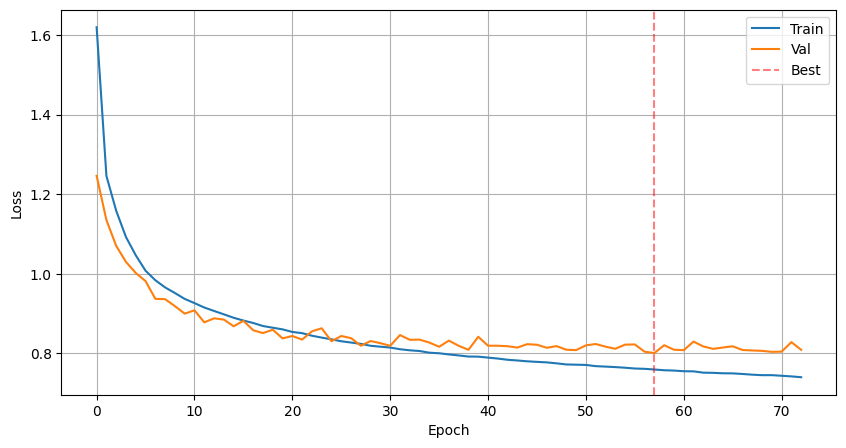

TEST SET RESULTS
Macro F1:    0.4757
Weighted F1: 0.9132

                precision    recall  f1-score   support

        Benign     1.0000    0.9739    0.9868     53750
      Analysis     0.2088    0.8966    0.3388        58
      Backdoor     0.1096    0.6029    0.1855        68
           DoS     0.3294    0.4194    0.3690       670
      Exploits     0.9066    0.5040    0.6478      4643
       Fuzzers     0.7469    0.5108    0.6067      4442
       Generic     0.5596    0.7295    0.6334       695
Reconnaissance     0.7818    0.6737    0.7237      2510
     Shellcode     0.1573    0.5873    0.2482       315
         Worms     0.0086    0.8108    0.0170        37

      accuracy                         0.8892     67188
     macro avg     0.4809    0.6709    0.4757     67188
  weighted avg     0.9513    0.8892    0.9132     67188



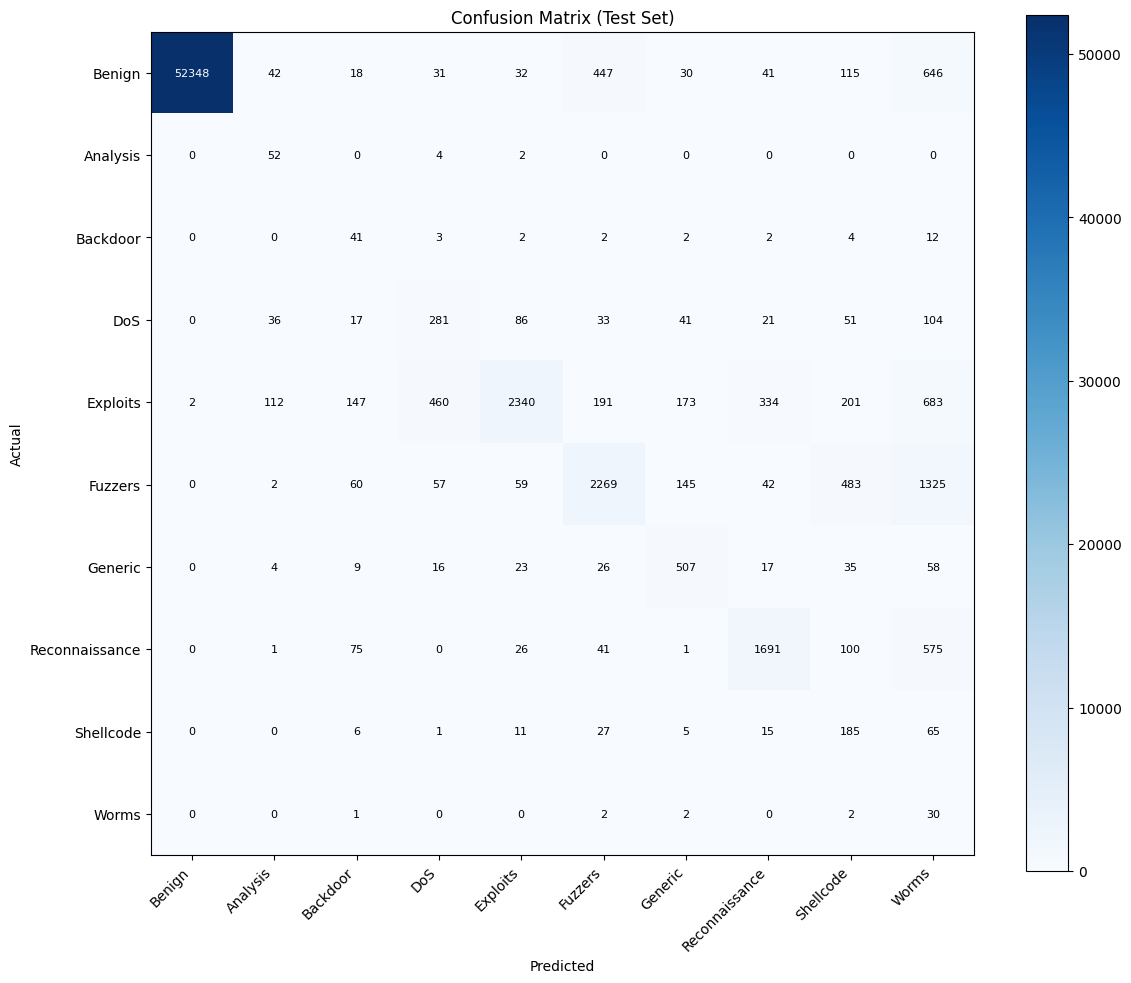

Model saved to /content/drive/MyDrive/Colab Notebooks/anomaly-models/tabtransformer_model.pth

SUMMARY
Architecture: TabTransformer (d_model=32, nhead=4, layers=4)
Parameters:   54,074
SMOTE:        target=25,083/class, k=5
  Original:   313,539 → 476,579
Batch size:   512
Optimizer:    AdamW (lr=5e-4, wd=1e-4)
Scheduler:    CosineAnnealingLR
Loss:         CrossEntropy (class-weighted + SMOTE)
Early stop:   patience=15
Training:     4312s (71.9 min)
Test Macro F1:   0.4757
Test Weighted F1: 0.9132


In [58]:
# ── Training loop ──
EPOCHS   = 150
PATIENCE = 15

train_losses = []
val_losses = []
best_val_loss = float("inf")
best_state = None
patience_counter = 0
start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_train_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(Xb)
        loss = criterion(outputs, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        epoch_train_loss += loss.item() * Xb.size(0)

    scheduler.step()
    epoch_train_loss /= len(train_dataset)

    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            outputs = model(Xb)
            loss = criterion(outputs, yb)
            epoch_val_loss += loss.item() * Xb.size(0)
    epoch_val_loss /= len(val_dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        elapsed = time.time() - start
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f} | "
              f"LR: {scheduler.get_last_lr()[0]:.2e} | {elapsed:.0f}s")

    if patience_counter >= PATIENCE:
        print(f"→ Early stopping at epoch {epoch}")
        break

total_time = time.time() - start
print(f"\nDone in {total_time:.0f}s ({total_time/60:.1f} min)")
print(f"Best val loss: {best_val_loss:.4f}")

# ── Plot ──
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.axvline(np.argmin(val_losses), color="red", ls="--", alpha=0.5, label="Best")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUT_DIR}/tabtransformer_training_curve.png", dpi=150)
plt.show()

# ── Evaluate on test set ──
model.load_state_dict(best_state)
model.eval()

test_dataset = TensorDataset(torch.from_numpy(X_test),
                              torch.from_numpy(y_test))
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_preds = []
all_labels = []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        outputs = model(Xb)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

macro_f1     = f1_score(all_labels, all_preds, average="macro")
weighted_f1  = f1_score(all_labels, all_preds, average="weighted")

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Macro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

# ── Confusion matrix ──
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar()
plt.xticks(range(n_classes), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(n_classes), CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
thresh = cm.max() / 2
for i in range(n_classes):
    for j in range(n_classes):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/tabtransformer_confusion_matrix.png", dpi=150)
plt.show()

# ── Save model ──
save_path = f"{OUT_DIR}/tabtransformer_model.pth"
torch.save({
    "model_state_dict": best_state,
    "n_features": n_features,
    "n_classes": n_classes,
    "d_model": D_MODEL,
    "nhead": NHEAD,
    "n_layers": N_LAYERS,
    "d_ff": D_FF,
    "class_names": CLASS_NAMES,
    "class_weights": class_weights.tolist(),
    "smote": True,
    "smote_strategy": float(target_per_class),
    "test_macro_f1": float(macro_f1),
    "test_weighted_f1": float(weighted_f1),
}, save_path)
print(f"Model saved to {save_path}")

# ── Summary ──
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Architecture: TabTransformer (d_model={D_MODEL}, nhead={NHEAD}, layers={N_LAYERS})")
print(f"Parameters:   {total_params:,}")
print(f"SMOTE:        target={target_per_class:,}/class, k=5")
print(f"  Original:   {len(X_train):,} → {len(X_train_smote):,}")
print(f"Batch size:   {BATCH_SIZE}")
print(f"Optimizer:    AdamW (lr=5e-4, wd=1e-4)")
print(f"Scheduler:    CosineAnnealingLR")
print(f"Loss:         CrossEntropy (class-weighted + SMOTE)")
print(f"Early stop:   patience={PATIENCE}")
print(f"Training:     {total_time:.0f}s ({total_time/60:.1f} min)")
print(f"Test Macro F1:   {macro_f1:.4f}")
print(f"Test Weighted F1: {weighted_f1:.4f}")